# Task 4: Functional Enrichment Analysis

Perform GO and pathway enrichment on detected modules.

Focus on the module containing **TP53**.

## 1. Setup & Load Data

In [1]:
import logging
from pathlib import Path
from typing import Dict, List
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")


def locate_repo_root() -> Path:
    here = Path().resolve()
    for base in [here, *here.parents]:
        if (base / "data").exists():
            return base
    raise FileNotFoundError("Could not locate repo root")


REPO_ROOT = locate_repo_root()
ARTIFACTS = REPO_ROOT / "labs/07_network_viz/assignments/artifacts"
TARGET_GENE = "TP53"
print(f"numpy {np.__version__}")
print(f"pandas {pd.__version__}")

numpy 2.1.3
pandas 2.2.3


In [2]:
# Load modules from Task 2
modules_path = ARTIFACTS / "task2_modules.csv"
assert modules_path.exists(), f"Modules not found: {modules_path}. Run Task 2 first."
modules_df = pd.read_csv(modules_path)
gene_modules = dict(zip(modules_df["Gene"], modules_df["Module"]))
logging.info("Loaded %d gene-module assignments", len(gene_modules))

module_sizes = modules_df["Module"].value_counts().sort_index()
print(f"Modules: {len(module_sizes)}")
for mod_id, size in module_sizes.items():
    print(f"  Module {mod_id}: {size} genes")

[INFO] Loaded 1948 gene-module assignments


Modules: 11
  Module 0: 511 genes
  Module 1: 43 genes
  Module 2: 498 genes
  Module 3: 2 genes
  Module 4: 268 genes
  Module 5: 3 genes
  Module 6: 527 genes
  Module 7: 2 genes
  Module 8: 86 genes
  Module 9: 6 genes
  Module 10: 2 genes


In [3]:
# Identify TP53's module
if TARGET_GENE in gene_modules:
    TP53_MODULE = gene_modules[TARGET_GENE]
    tp53_module_genes = modules_df[modules_df["Module"] == TP53_MODULE]["Gene"].tolist()
    print(f"\n*** {TARGET_GENE} is in Module {TP53_MODULE} ***")
    print(f"Module size: {len(tp53_module_genes)} genes")
    print(f"First 20 genes: {tp53_module_genes[:20]}")
else:
    TP53_MODULE = None
    tp53_module_genes = []
    print(f"WARNING: {TARGET_GENE} not found!")


*** TP53 is in Module 4 ***
Module size: 268 genes
First 20 genes: ['ABCB10', 'AC017002.2', 'ACADSB', 'ACSL3', 'ADD3', 'AGL', 'AJ420595 /// GOPC', 'AK021804', 'AK021977', 'AK022030 /// TROVE2', 'AK025288', 'AK026714 /// PELI1', 'AK057978 /// MKLN1', 'ALCAM', 'ANK3', 'ANKRD20A1 /// ANKRD20A11P /// ANKRD20A2 /// ANKRD20A3 /// ANKRD20A4 /// ANKRD20A5P /// ANKRD20A9P /// LOC102723891 /// LOC102725051', 'ANKRD29', 'ANKRD36B', 'ANP32E', 'ANXA1']


## 2. Enrichment with g:Profiler

In [4]:
try:
    from gprofiler import GProfiler

    GPROFILER_AVAILABLE = True
    print("[OK] g:Profiler available")
except ImportError:
    GPROFILER_AVAILABLE = False
    print("[INFO] g:Profiler not installed. Using requests fallback.")
    print("       To install: pip install gprofiler-official")

[OK] g:Profiler available


In [5]:
def run_gprofiler_enrichment(
    gene_list: List[str], organism: str = "hsapiens"
) -> pd.DataFrame:
    if GPROFILER_AVAILABLE:
        gp = GProfiler(return_dataframe=True)
        return gp.profile(
            organism=organism,
            query=gene_list,
            sources=["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC"],
            user_threshold=0.05,
            significance_threshold_method="fdr",
        )
    else:
        import requests

        url = "https://biit.cs.ut.ee/gprofiler/api/gost/profile/"
        payload = {
            "organism": organism,
            "query": gene_list,
            "sources": ["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC"],
            "user_threshold": 0.05,
        }
        response = requests.post(url, json=payload)
        if response.status_code == 200:
            data = response.json()
            if "result" in data and data["result"]:
                return pd.DataFrame(data["result"])
        return pd.DataFrame()


print("Enrichment function ready.")

Enrichment function ready.


## 3. Analyze TP53's Module

In [6]:
if tp53_module_genes:
    print(
        f"Running enrichment on Module {TP53_MODULE} ({len(tp53_module_genes)} genes)..."
    )
    tp53_enrichment = run_gprofiler_enrichment(tp53_module_genes)
    if len(tp53_enrichment) > 0:
        print(f"Found {len(tp53_enrichment)} significant terms!")
        if "source" in tp53_enrichment.columns:
            for source in tp53_enrichment["source"].unique():
                print(
                    f"  {source}: {len(tp53_enrichment[tp53_enrichment['source'] == source])} terms"
                )
    else:
        print("No significant enrichment found.")
else:
    tp53_enrichment = pd.DataFrame()
    print("Cannot run enrichment - TP53 module not identified.")

Running enrichment on Module 4 (268 genes)...
Found 45 significant terms!
  GO:CC: 27 terms
  GO:MF: 3 terms
  GO:BP: 15 terms


In [7]:
if len(tp53_enrichment) > 0:
    display_cols = [
        c
        for c in [
            "source",
            "native",
            "name",
            "p_value",
            "term_size",
            "intersection_size",
        ]
        if c in tp53_enrichment.columns
    ]
    print(f"\nTOP ENRICHED TERMS - Module {TP53_MODULE}")
    if "p_value" in tp53_enrichment.columns:
        top_terms = tp53_enrichment.nsmallest(20, "p_value")[display_cols]
    else:
        top_terms = tp53_enrichment.head(20)[display_cols]
    display(top_terms)


TOP ENRICHED TERMS - Module 4


,source,native,name,p_value,term_size,intersection_size
0,GO:CC,GO:0043230,extracellular organelle,0.000004,2142,46
1,GO:CC,GO:1903561,extracellular vesicle,0.000004,2141,46
2,GO:CC,GO:0065010,extracellular membrane-bounded organelle,0.000004,2142,46
3,GO:CC,GO:0070062,extracellular exosome,0.000005,2111,45
4,GO:CC,GO:0031982,vesicle,0.000006,4033,68
5,GO:CC,GO:0005737,cytoplasm,0.000006,12527,150
6,GO:CC,GO:0016020,membrane,0.000039,9953,125
7,GO:MF,GO:0005515,protein binding,0.000198,15123,179
8,GO:CC,GO:0031090,organelle membrane,0.000232,3842,61
9,GO:CC,GO:0043226,organelle,0.001209,16936,177


## 4. Visualization

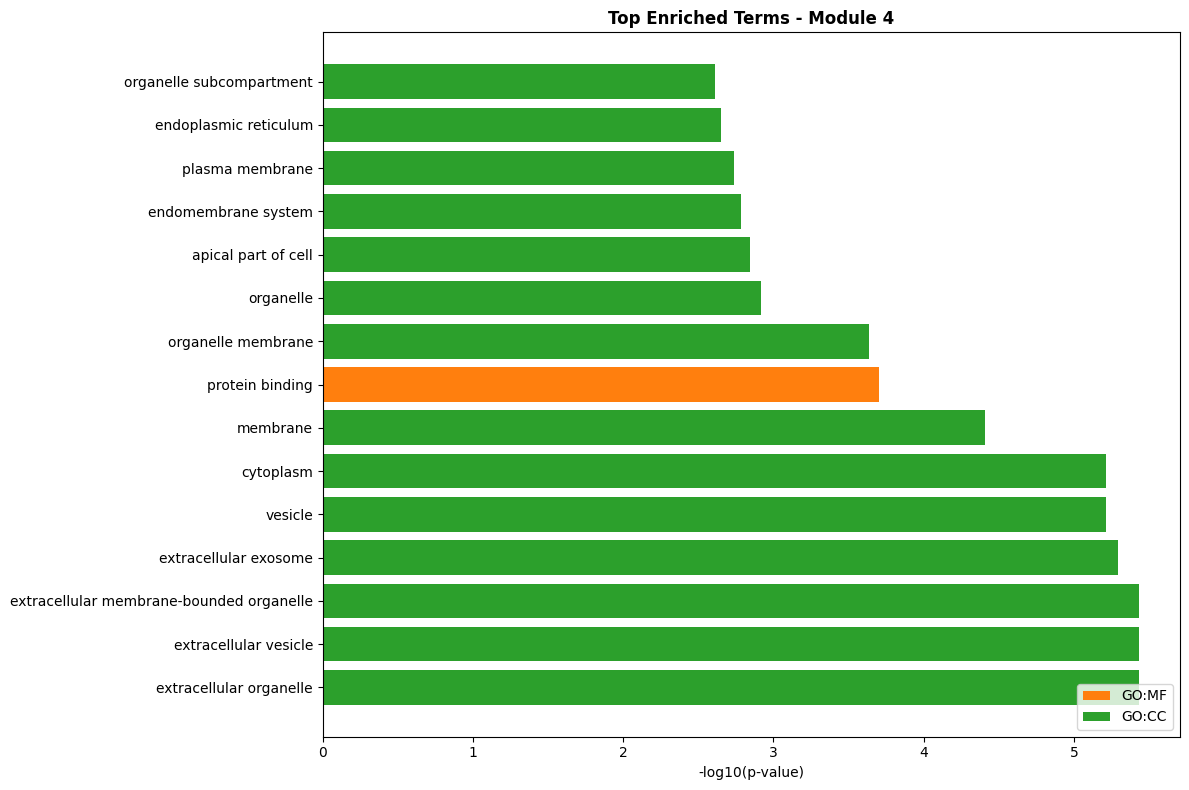

In [8]:
import matplotlib.pyplot as plt

if len(tp53_enrichment) > 0 and "name" in tp53_enrichment.columns:
    fig, ax = plt.subplots(figsize=(12, 8))
    if "p_value" in tp53_enrichment.columns:
        plot_data = tp53_enrichment.nsmallest(15, "p_value").copy()
        plot_data["-log10(p)"] = -np.log10(plot_data["p_value"])
    else:
        plot_data = tp53_enrichment.head(15).copy()
        plot_data["-log10(p)"] = 1
    plot_data["name_short"] = plot_data["name"].apply(
        lambda x: x[:40] + "..." if len(str(x)) > 40 else x
    )
    source_colors = {
        "GO:BP": "#1f77b4",
        "GO:MF": "#ff7f0e",
        "GO:CC": "#2ca02c",
        "KEGG": "#d62728",
        "REAC": "#9467bd",
    }
    colors = (
        [source_colors.get(s, "gray") for s in plot_data["source"]]
        if "source" in plot_data.columns
        else "steelblue"
    )
    ax.barh(range(len(plot_data)), plot_data["-log10(p)"], color=colors)
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels(plot_data["name_short"])
    ax.set_xlabel("-log10(p-value)")
    ax.set_title(
        f"Top Enriched Terms - Module {TP53_MODULE}", fontsize=12, fontweight="bold"
    )
    if "source" in plot_data.columns:
        from matplotlib.patches import Patch

        legend_elements = [
            Patch(facecolor=c, label=s)
            for s, c in source_colors.items()
            if s in plot_data["source"].values
        ]
        ax.legend(handles=legend_elements, loc="lower right")
    plt.tight_layout()
    plt.savefig(ARTIFACTS / "task4_enrichment.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No enrichment data to visualize")

## 5. Export Results

In [9]:
if len(tp53_enrichment) > 0:
    enrichment_path = ARTIFACTS / "task4_enrichment.csv"
    tp53_enrichment.to_csv(enrichment_path, index=False)
    logging.info("[OK] Enrichment saved: %s", enrichment_path)

if tp53_module_genes:
    genes_path = ARTIFACTS / "task4_tp53_module_genes.txt"
    with open(genes_path, "w") as f:
        f.write("\n".join(tp53_module_genes))
    logging.info("[OK] TP53 module genes saved: %s", genes_path)

[INFO] [OK] Enrichment saved: /home/rbals/git/daha-bdhb/BDHB-lab/labs/07_network_viz/assignments/artifacts/task4_enrichment.csv
[INFO] [OK] TP53 module genes saved: /home/rbals/git/daha-bdhb/BDHB-lab/labs/07_network_viz/assignments/artifacts/task4_tp53_module_genes.txt


In [10]:
print(f"\n{'=' * 60}")
print("TASK 4 COMPLETE - Functional Enrichment")
print(f"{'=' * 60}")
print(f"TP53 Module: {TP53_MODULE}")
print(f"Genes in module: {len(tp53_module_genes)}")
print(f"Enriched terms: {len(tp53_enrichment)}")
print(f"\n*** Lab 7 Assignment Complete! ***")
print(f"\nDeliverables:")
print(f"  1. task2_modules.csv")
print(f"  2. task3_network.png")
print(f"  3. task2_hub_genes.csv")


TASK 4 COMPLETE - Functional Enrichment
TP53 Module: 4
Genes in module: 268
Enriched terms: 45

*** Lab 7 Assignment Complete! ***

Deliverables:
  1. task2_modules.csv
  2. task3_network.png
  3. task2_hub_genes.csv
